<a href="https://colab.research.google.com/github/Atharv26j13/2/blob/main/24b_24_7_26_Road_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
files = files.upload()

Saving test_image.jpg to test_image (2).jpg


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def canny(image):
  gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  blur = cv2.GaussianBlur(gray, (5, 5), 0)
  canny = cv2.Canny(blur, 50, 150)
  return canny

def roi(image):
  height = 700
  polygons = np.array([[250,height],(1000,height),(600,250)])
  mask = np.zeros_like(image)
  cv2.fillPoly(mask, np.int32([polygons]), 255)
  masked_image = cv2.bitwise_and(image, mask)
  return masked_image

def display_lines(image,lines):
  line_image = np.zeros_like(image)
  if lines is not None:
    for line in lines:
      x1, y1, x2, y2 = line.reshape(4)
      cv2.line(line_image, (x1, y1), (x2, y2), (255,0,0),10)
  return line_image

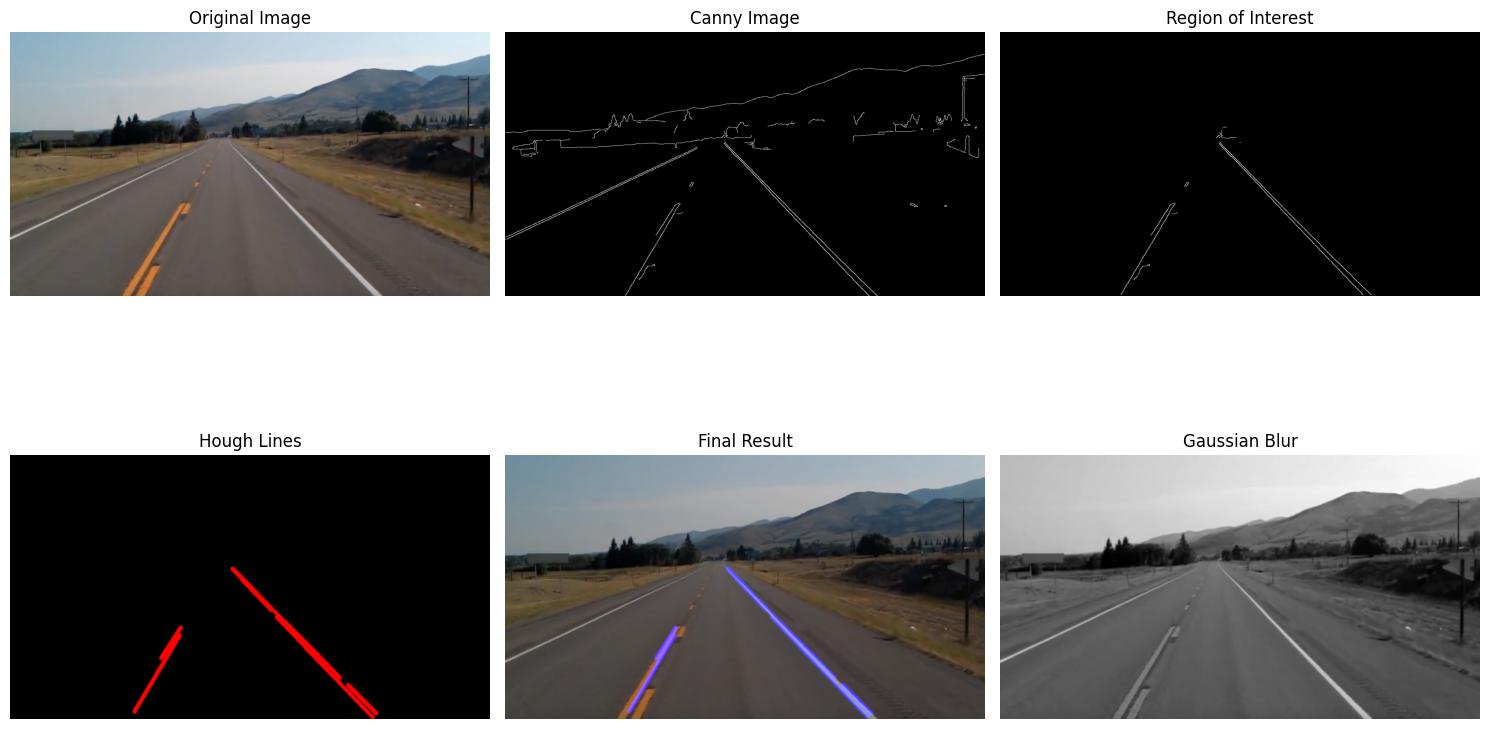

In [16]:
def detect_lanes(image_path):
  image = cv2.imread(image_path)
  lane_image = np.copy(image)
  canny_image = canny(lane_image)
  cropped_image = roi(canny_image)
  lines = cv2.HoughLinesP(cropped_image, 2, np.pi/180, 100, np.array([]), minLineLength=40, maxLineGap=5)
  line_image = display_lines(lane_image, lines )
  combo_image = cv2.addWeighted(lane_image, 0.8, line_image, 1, 1)
  plt.figure(figsize=(15,10))

  plt.subplot(2,3,1)
  plt.title('Original Image')
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')

  plt.subplot(2,3,2)
  plt.title('Canny Image')
  plt.imshow(canny_image, cmap='gray')
  plt.axis('off')

  plt.subplot(2,3,3)
  plt.title('Region of Interest')
  plt.imshow(cropped_image, cmap='gray')
  plt.axis('off')

  plt.subplot(2,3,4)
  plt.title('Hough Lines')
  plt.imshow(line_image, cmap='gray')
  plt.axis('off')

  plt.subplot(2,3,5)
  plt.title('Final Result')
  plt.imshow(cv2.cvtColor(combo_image, cv2.COLOR_BGR2RGB))
  plt.axis('off')

  plt.subplot(2,3,6)
  gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  blur = cv2.GaussianBlur(gray, (5, 5), 0)
  plt.title("Gaussian Blur")
  plt.imshow(blur, cmap='gray')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

if __name__ == "__main__":
  detect_lanes("test_image.jpg")